In [1]:
import pandas as pd              # For handling data in table form (DataFrame)
import numpy as np               # For numerical calculations and arrays
import matplotlib.pyplot as plt  # For creating graphs and plots
import seaborn as sns            # For better-looking statistical graphs
import datetime as dt            # For working with dates and time
import time                      # For tracking time or adding delays

import yfinance as yf            # Download stock market data from Yahoo Finance
from pandas_datareader import data as pdr  # Alternative source to fetch financial data
from scipy import stats          # For statistical calculations (mean, variance, etc.)

sns.set_style('whitegrid')       # Sets graph background style to white grid
# Shows plots directly inside Jupyter Notebook
%matplotlib inline

In [2]:
# Define your portfolio and date range
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
weights = np.array([0.25, 0.25, 0.25, 0.25])

start = dt.datetime(2020, 1, 1)   # start date for data
end = dt.datetime.today()         # end date (today)

# Create empty DataFrame to store prices
prices = pd.DataFrame()

for ticker in tickers:
    print(f"Fetching {ticker}...", end=" ")

    try:
        # Download data using yfinance
        df = yf.Ticker(ticker).history(
            start=start.strftime('%Y-%m-%d'),
            end=end.strftime('%Y-%m-%d'),
            auto_adjust=True
        )

        series = df['Close']
        prices[ticker] = series
        print("done (yfinance)")

    except Exception as e:
        # Fallback to stooq if yfinance fails
        print(f"failed yfinance ({e}); using stooq", end=" ")

        df2 = pdr.DataReader(ticker, 'stooq', start, end)
        df2 = df2.sort_index()

        series = df2['Close']
        prices[ticker] = series

        print("done (stooq)")

    time.sleep(1)  # pause to avoid request limits

# Show raw data
print(prices.head(), "\n")

# Clean data
prices = prices.dropna(how='all').ffill().bfill()

# Quick check
print(prices.head(), "\n")
print(prices.size)

Fetching AAPL... done (yfinance)
Fetching MSFT... done (yfinance)
Fetching GOOGL... done (yfinance)
Fetching AMZN... done (yfinance)
                                AAPL        MSFT      GOOGL       AMZN
Date                                                                  
2020-01-02 00:00:00-05:00  72.333870  151.829544  67.832497  94.900497
2020-01-03 00:00:00-05:00  71.630646  149.939026  67.477654  93.748497
2020-01-06 00:00:00-05:00  72.201408  150.326584  69.276215  95.143997
2020-01-07 00:00:00-05:00  71.861839  148.955948  69.142403  95.343002
2020-01-08 00:00:00-05:00  73.017838  151.328568  69.634537  94.598503 

                                AAPL        MSFT      GOOGL       AMZN
Date                                                                  
2020-01-02 00:00:00-05:00  72.333870  151.829544  67.832497  94.900497
2020-01-03 00:00:00-05:00  71.630646  149.939026  67.477654  93.748497
2020-01-06 00:00:00-05:00  72.201408  150.326584  69.276215  95.143997
2020-01-07 00

In [3]:
# Log-return = ln(P_t / P_{t-1})
logR = np.log(prices / prices.shift(1)).dropna()   #dropna() used even if ffill().bfill() used as 
print(logR.head(),"\n\n")
print(logR.size)

# Here, 2-Jan data is removed, because we shifted 1 down via using shift(1) and used dropna()

                               AAPL      MSFT     GOOGL      AMZN
Date                                                             
2020-01-03 00:00:00-05:00 -0.009769 -0.012530 -0.005245 -0.012213
2020-01-06 00:00:00-05:00  0.007937  0.002581  0.026305  0.014776
2020-01-07 00:00:00-05:00 -0.004714 -0.009160 -0.001933  0.002089
2020-01-08 00:00:00-05:00  0.015958  0.015803  0.007092 -0.007839
2020-01-09 00:00:00-05:00  0.021018  0.012416  0.010443  0.004788 


6528


In [4]:
summary = pd.DataFrame({'Mean':logR.mean(),'Variance':logR.var(),'Skewness':logR.skew(), 'Kurtosis':logR.kurtosis()})
summary

,Mean,Variance,Skewness,Kurtosis
AAPL,0.000889,0.000391,0.009104,6.333117
MSFT,0.000579,0.000356,-0.230972,7.388284
GOOGL,0.001023,0.000415,-0.095041,3.705194
AMZN,0.000575,0.000497,-0.074945,4.153237


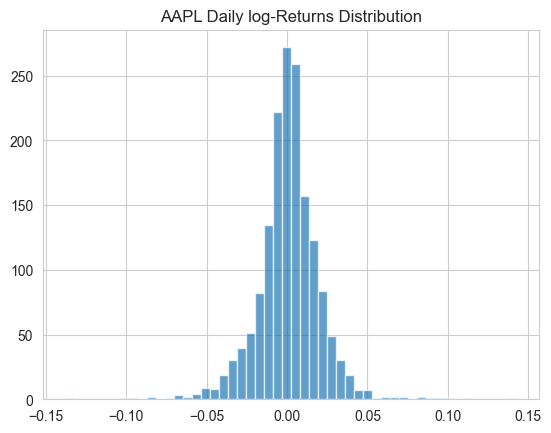

In [5]:
# Plot one example series for visual check
#You'll see a bell-shaped histogram.
logR['AAPL'].hist(bins=50,alpha=0.7)
plt.title("AAPL Daily log-Returns Distribution")
plt.show()

In [6]:
# Mean and standard deviation of log returns
mu_norm = logR.stack().mean()
sigma_norm = logR.stack().std(ddof=1)

#print(mu_norm)
#print(sigma_norm)


#  95% Confidence Interval for Mean

N = logR.size  # total number of observations

z95 = stats.norm.ppf(0.975)  # 95% z-value (1.96)

# Correct CI formula for mean
ci_mu_norm = (
    mu_norm - z95 * sigma_norm / np.sqrt(N),
    mu_norm + z95 * sigma_norm / np.sqrt(N)
)

#print("\n95% CI for Mean\n:", ci_mu_norm)


#95% Confidence Interval for Std Dev ( via chi-square)

df = N - 1  # degrees of freedom

chi2_low, chi2_high = stats.chi2.ppf([0.025, 0.975], df)

ci_sigma_norm = (
    sigma_norm * np.sqrt(df / chi2_high),
    sigma_norm * np.sqrt(df / chi2_low)
)
#print(ci_sigma_norm,"\n\n")

print("\nNormal Fit Results:")
print(f"μ (Mean) = {mu_norm:.5f}, 95% CI = {ci_mu_norm}")
print(f"σ (Std Dev) = {sigma_norm:.5f}, 95% CI = {ci_sigma_norm}")


Normal Fit Results:
μ (Mean) = 0.00077, 95% CI = (np.float64(0.0002725316510030954), np.float64(0.001260305577956036))
σ (Std Dev) = 0.02036, 95% CI = (np.float64(0.02001629506404097), np.float64(0.020715001266589678))


In [7]:
#4.2 Fit Student's t

#fit t-distribution to the pooled returns
# returns_flat = all asset returns concatenated
returns_flat = logR.stack().values
df_t, mu_t, sigma_t = stats.t.fit(returns_flat)

In [8]:
import numpy as np
from scipy import stats

B = 200   # reduce from 1000 → 200 (huge speed boost)

estimates = np.array([
    stats.t.fit(np.random.choice(returns_flat, size=min(500, len(returns_flat)), replace=True))
    for _ in range(B)
])

ci_mu_t = np.percentile(estimates[:, 1], [2.5, 97.5])
ci_sigma_t = np.percentile(estimates[:, 2], [2.5, 97.5])

df_t, mu_t, sigma_t = stats.t.fit(returns_flat)

print("\nStudent's t fit:")
print(f"df = {df_t:.1f}, μ = {mu_t:.5f}, σ = {sigma_t:.5f}")
print(f"95% CI for μ (bootstrap): {ci_mu_t}")
print(f"95% CI for σ (bootstrap): {ci_sigma_t}")


Student's t fit:
df = 3.7, μ = 0.00103, σ = 0.01411
95% CI for μ (bootstrap): [-0.00050379  0.00258064]
95% CI for σ (bootstrap): [0.01260867 0.01563791]


In [9]:
# Parametric VaR (Value at risk) under Normal:
#  VaR = - [μ_p + σ_p . z_{0.05} ]
# where μ_p, σ_p are portfolio mean & vol.
# Compute portfolio returns:
portR = logR.dot(weights)
#prints(portR,"\n\n")

μ_p = portR.mean()
σ_p  = portR.std(ddof=1)
print(f"Portfolio return Mean is:{μ_p}\n")
print(f"Portfolio return Standarad Deviation is:{σ_p}\n")

z05 = stats.norm.ppf(0.05)
print("ppf value:",z05,"\n")

vaR_norm = -(μ_p + σ_p *z05)
print(vaR_norm)

Portfolio return Mean is:0.0007664186144795657

Portfolio return Standarad Deviation is:0.01724236130129841

ppf value: -1.6448536269514729 

0.027594741909168843


In [10]:
# Parametric VaR under Students's t:
# t05 = t.ppf(0.05, df_f0)
t05 = stats.t.ppf(0.05, df_t)
print(t05,"\n")

vaR_t = -(mu_t + sigma_t *z05) *1 #1-day
print(vaR_t)

-2.188757425382405 

0.02217453770647298


In [11]:
# Historical VaR (non-parametric):-
hist_var = -np.percentile(portR, 5)

print("1-day 95% VaR:")
print(f" Parametric(Normal):   {vaR_norm:.5f}")
print(f" Parametric(Student's t):   {vaR_t:.5f}")
print(f" Historical VaR:   {hist_var:.5f}")

1-day 95% VaR:
 Parametric(Normal):   0.02759
 Parametric(Student's t):   0.02217
 Historical VaR:   0.02727


In [12]:
# One-sample t-test: H0 μ=0 vs H1: μ=!0
t_stat, p_val = stats.ttest_1samp(portR, 0.0)
print("one-Sample t-test on portfolio daily returns:")
print(f"t-static = {t_stat:.3f}, p-value = {p_val:.3f}")

if p_val < 0.05:
  print("  -> Reject H0: mean return is significantly different from zero.")
else:
  print("  -> Fail to reject H0: mean return is not significantly different from zero.")

one-Sample t-test on portfolio daily returns:
t-static = 1.796, p-value = 0.073
  -> Fail to reject H0: mean return is not significantly different from zero.


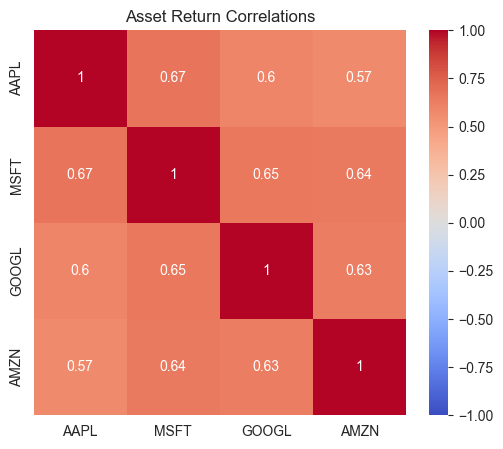

Weighted avg σ: 0.02032
Portfolio σ: 0.01724
Diversification benefit: 0.0031


In [13]:
# Correlation & Diversification Benefits
import seaborn as sns

# a) Correlation heatmap
corr = logR.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Asset Return Correlations")
plt.show()

#b) Diversification benefits
σ_i = logR.std()                                  #individual volatilities
σ_weighted = np.dot(weights, σ_i)                 #native weighted avg
σ_portfolio = σ_p                                 # from earlier
print(f"Weighted avg σ: {σ_weighted:.5f}")
print(f"Portfolio σ: {σ_portfolio:.5f}")
print(f"Diversification benefit: { σ_weighted - σ_portfolio :.4f}")


Max Drawdown: -43.98%
from 2021-12-10 to 2023-01-05


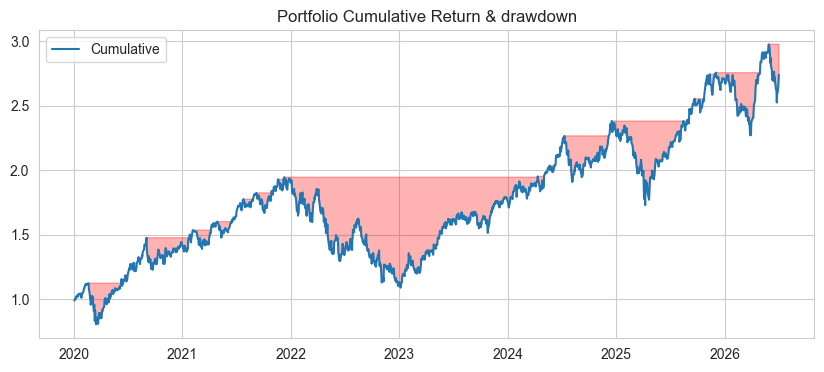

In [14]:
# Max Drawdown
# For Portfolio: cum_port = (port + 1).cumprod()
#print(portR,"\n\n")
cum_port = (portR +1).cumprod()
#print(cum_port,"\n\n")

rolling_max = cum_port.cummax()
#print(rolling_max,"\n\n")

drawdown = (cum_port - rolling_max) / rolling_max
#print(drawdown,"\n\n")

max_dd = drawdown.min()
end_date = drawdown.idxmin()
start_date = cum_port[:end_date].idxmax()   #Before the worst loss happened,when was the portfolio at its highest?

print(f"Max Drawdown: {max_dd:.2%}")
print(f"from {start_date.date()} to {end_date.date()}")

#plot
plt.figure(figsize=(10,4))
plt.plot(cum_port, label='Cumulative')
plt.fill_between(drawdown.index, cum_port, rolling_max, where=drawdown<0, color='red',alpha=0.3)
plt.title("Portfolio Cumulative Return & drawdown")
plt.legend()
plt.show()

In [15]:
# Expected Shortfall (CVaR at 95%)
alpha = 0.05    #worst 5% cases
#Historical ES
es_hist = -portR[portR <= np.percentile(portR, 5)].mean()
#Parametric ES under Normal: 
es_norm = -(μ_p - σ_p * stats.norm.pdf(z05) / alpha)

print(f"Historical ES (95%): {es_hist:.5f}")
print(f"Parametric ES under Normal (95%) : {es_norm:.5f}")

Historical ES (95%): 0.04018
Parametric ES under Normal (95%) : 0.03480


In [17]:
# VaR Backtesting
# for simplicity use constant VaR_norm
exceptions = portR < -vaR_norm
print(exceptions)

num_exc = exceptions.sum()
print(f"Number of exceptions: {num_exc}")

total = len(portR)
#print(f"Exceptions: {num_exc/total*100:.2f}%")
print(f"Exceptions: {num_exc} / {total} days ({num_exc / total:.2f}, expected ~5%)")

Date
2020-01-03 00:00:00-05:00    False
2020-01-06 00:00:00-05:00    False
2020-01-07 00:00:00-05:00    False
2020-01-08 00:00:00-05:00    False
2020-01-09 00:00:00-05:00    False
                             ...  
2026-06-26 00:00:00-04:00    False
2026-06-29 00:00:00-04:00    False
2026-06-30 00:00:00-04:00    False
2026-07-01 00:00:00-04:00    False
2026-07-02 00:00:00-04:00    False
Length: 1632, dtype: bool
Number of exceptions: 81
Exceptions: 81 / 1632 days (0.05, expected ~5%)


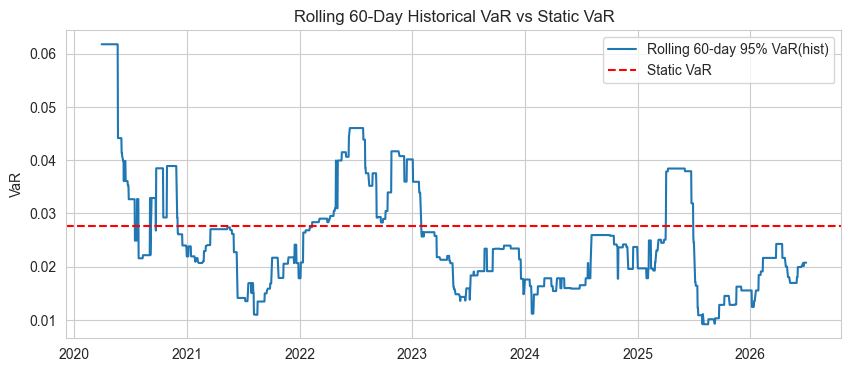

In [18]:
# Rolling 60-day VaR
window = 60
roll_var = portR.rolling(window).quantile(0.05).dropna()
plt.figure(figsize=(10,4))
plt.plot(-roll_var, label='Rolling 60-day 95% VaR(hist)')
plt.axhline(vaR_norm, color='red',linestyle='--', label='Static VaR')
plt.title("Rolling 60-Day Historical VaR vs Static VaR")
plt.ylabel('VaR')
plt.legend()
plt.show()


In [19]:
# 12. Jarque-Bera Normality Test
jb_stat, jb_p = stats.jarque_bera(portR)
print(f"Jarque-Bera Test: statistic = {jb_stat:.2f}, p-value = {jb_p:.3f}")

if jb_p < 0.05:
  print('  -> Reject H0: returns are not normally distributed at 5% level.')
else:
  print("  -> Fail to reject H0: returns are normally distributed.")

Jarque-Bera Test: statistic = 1628.00, p-value = 0.000
  -> Reject H0: returns are not normally distributed at 5% level.
